# Ultra-Efficient CNN with Global Average Pooling (GAP)

This notebook implements an **ultra-efficient CNN** on MNIST and provides deep inspection tools:

1. **Global Average Pooling (GAP)**:
   Instead of flattening $16 \times 14 \times 14 = 3,136$ values into an enormous linear layer, each of the 16 feature maps is averaged into **1 single number**.
   $$\text{Conv4 Output: } [16, 14, 14] \xrightarrow{\text{Global Avg Pool}} \text{Vector of } \mathbf{16 \text{ values}} \xrightarrow{\text{Linear}(16, 10)} \mathbf{10 \text{ Class Probabilities}}$$
   * **Original classifier (500 neurons)**: $1,568,500$ parameters
   * **GAP classifier**: **Only 170 parameters** ($99.99\%$ reduction!)

2. **Layer Parameter Inspector**: Inspect the **exact raw numbers** (weights and biases) of any layer.
3. **Step-by-Step Image Transformation**: Watch an MNIST image transform layer-by-layer from pixels to the 16 pooled values to the final prediction!


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Auto-detect best device: Apple Silicon (MPS), NVIDIA (CUDA), or CPU
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")


Using device: mps


In [5]:
# Standard MNIST transformations (Convert PIL image to FloatTensor in [0, 1])
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"Loaded {len(train_dataset):,} training images and {len(test_dataset):,} test images.")


Loaded 60,000 training images and 10,000 test images.


## 1. Ultra-Efficient Architecture: Global Average Pooling (GAP)

Modern CNNs (like ResNet) do not flatten multi-channel maps into huge linear layers.
Instead, they use **`nn.AdaptiveAvgPool2d((1, 1))`**:
* It averages each $14 \times 14$ map down to **1 number**.
* Output is a compact vector of **16 feature scores**.
* A tiny `nn.Linear(16, 10)` completes the classification with just **170 parameters**!


In [6]:
class UltraEfficientCNN(nn.Module):
    def __init__(self):
        super(UltraEfficientCNN, self).__init__()
        
        # Convolutional Feature Extractor
        self.convolutional = nn.Sequential(
            # Block 1 (8 features, 28x28)
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1),  # [0] Conv1
            nn.ReLU(),                                                                      # [1] ReLU
            nn.Conv2d(in_channels=8, out_channels=8, kernel_size=3, stride=1, padding=1),  # [2] Conv2
            nn.ReLU(),                                                                      # [3] ReLU
            
            # Spatial Downsampling (28x28 -> 14x14)
            nn.MaxPool2d(kernel_size=2, stride=2),                                          # [4] MaxPool
            
            # Block 2 (16 features, 14x14)
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1), # [5] Conv3
            nn.ReLU(),                                                                      # [6] ReLU
            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, stride=1, padding=1),# [7] Conv4
            nn.ReLU(),                                                                      # [8] ReLU
        )
        
        # Global Average Pooling: collapses each 14x14 map into 1 single average value!
        # Input: [batch, 16, 14, 14] -> Output: [batch, 16, 1, 1]
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        
        # Tiny Classifier: connects 16 pooled summary features -> 10 digit classes
        # Weights: 16 * 10 = 160 | Biases: 10 | Total: 170 parameters!
        self.classifier = nn.Linear(16, 10)

    def forward(self, x):
        x = self.convolutional(x) # [batch, 16, 14, 14]
        x = self.gap(x)           # [batch, 16, 1, 1]
        x = x.view(x.size(0), -1) # Flatten to [batch, 16]
        x = self.classifier(x)    # [batch, 10]
        return x

model = UltraEfficientCNN().to(device)

# Parameter comparison
conv_params = sum(p.numel() for p in model.convolutional.parameters())
gap_params  = sum(p.numel() for p in model.gap.parameters()) # 0
fc_params   = sum(p.numel() for p in model.classifier.parameters())
total_params = conv_params + fc_params

orig_fc_params = (3136 * 500 + 500) + (500 * 10 + 10)
orig_total = conv_params + orig_fc_params

print("=" * 68)
print("                    PARAMETER COMPARISON")
print("=" * 68)
print(f"Original Model (500 neurons):   {orig_total:,} params  (FC alone: {orig_fc_params:,})")
print(f"Ultra-Efficient GAP Model:      {total_params:,} params  (FC alone: {fc_params:,})")
print(f"Total Parameters Saved:         {orig_total - total_params:,} weights (-{(1 - total_params/orig_total)*100:.2f}%)")
print("=" * 68)


                    PARAMETER COMPARISON
Original Model (500 neurons):   1,577,662 params  (FC alone: 1,573,510)
Ultra-Efficient GAP Model:      4,322 params  (FC alone: 170)
Total Parameters Saved:         1,573,340 weights (-99.73%)


## 2. Fast Training & Evaluation (3 Epochs)

Because this model has **only ~4,300 total parameters in the entire network**, it trains with lightning speed and generalizes cleanly without overfitting!


In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
criterion = nn.CrossEntropyLoss()

num_epochs = 3
model.train()

print("Starting training...")
for epoch in range(1, num_epochs + 1):
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += data.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = (correct / total) * 100
    print(f"Epoch {epoch}/{num_epochs} - Loss: {epoch_loss:.4f} - Train Acc: {epoch_acc:.2f}%")

# Evaluate on test set
model.eval()
test_correct = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        pred = output.argmax(dim=1)
        test_correct += (pred == target).sum().item()

test_acc = (test_correct / len(test_dataset)) * 100
print(f"\n>>> Final Test Accuracy: {test_acc:.2f}% <<<")


Starting training...
Epoch 1/3 - Loss: 1.2720 - Train Acc: 55.47%
Epoch 2/3 - Loss: 0.3724 - Train Acc: 88.83%
Epoch 3/3 - Loss: 0.2382 - Train Acc: 92.73%

>>> Final Test Accuracy: 94.41% <<<


## 3. Layer Parameter Inspector (Raw Numbers & Visuals)

Use the helper functions below to inspect the **exact numerical weights and biases** of any convolutional or classifier layer.


Layer Name                     Weight Shape              Bias Shape      Param Count
--------------------------------------------------------------------------------
convolutional.0.weight         [8, 1, 3, 3]              [8]             80        
convolutional.2.weight         [8, 8, 3, 3]              [8]             584       
convolutional.5.weight         [16, 8, 3, 3]             [16]            1,168     
convolutional.7.weight         [16, 16, 3, 3]            [16]            2,320     
classifier.weight              [10, 16]                  [10]            170       
=== Conv Layer 2 | Filter 0 ===
Filter Shape: [8, 3, 3] | Bias: +0.2042


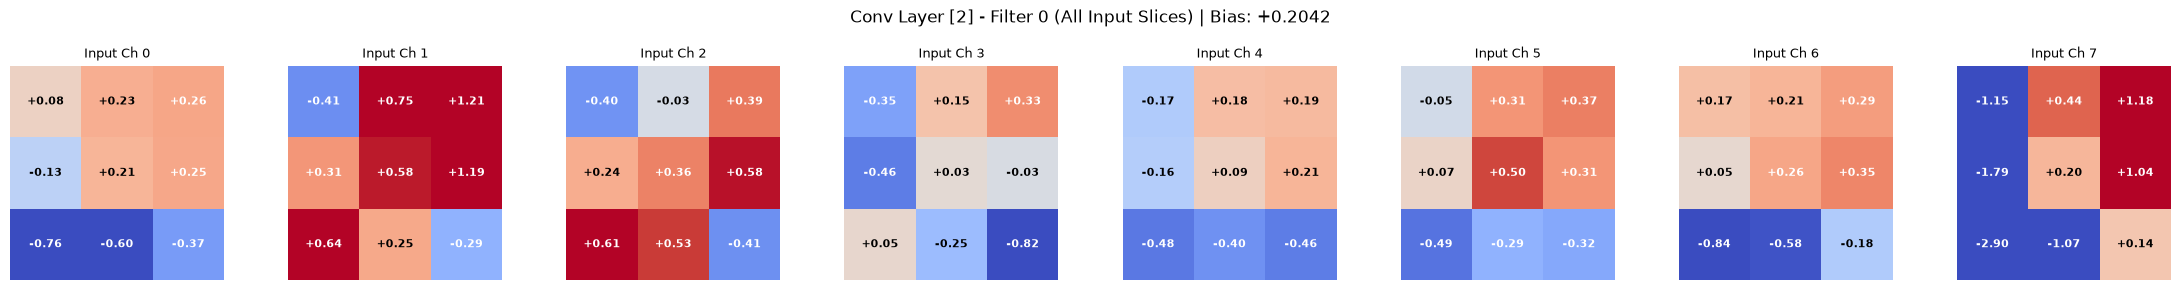

In [10]:
def print_layer_summary():
    print(f"{'Layer Name':<30} {'Weight Shape':<25} {'Bias Shape':<15} {'Param Count':<10}")
    print("-" * 80)
    for name, param in model.named_parameters():
        if 'weight' in name:
            b_name = name.replace('weight', 'bias')
            bias = dict(model.named_parameters()).get(b_name)
            b_shape = str(list(bias.shape)) if bias is not None else "None"
            count = param.numel() + (bias.numel() if bias is not None else 0)
            print(f"{name:<30} {str(list(param.shape)):<25} {b_shape:<15} {count:<10,}")

print_layer_summary()

def inspect_conv_filter(layer_idx=0, filter_idx=0):
    """Inspects a specific filter: prints the numerical 3x3 matrix and renders heatmaps with annotated numbers."""
    layer = model.convolutional[layer_idx]
    if not isinstance(layer, nn.Conv2d):
        print(f"Layer index {layer_idx} is {type(layer).__name__}, not Conv2d!")
        return
    
    weights = layer.weight.detach().cpu()[filter_idx] # shape: [in_channels, 3, 3]
    bias = layer.bias.detach().cpu()[filter_idx].item()
    
    print(f"=== Conv Layer {layer_idx} | Filter {filter_idx} ===")
    print(f"Filter Shape: {list(weights.shape)} | Bias: {bias:+.4f}")
    
    in_channels = weights.shape[0]
    cols = min(in_channels, 8)
    rows = (in_channels + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.8, rows * 2.8), squeeze=False)
    for ch in range(in_channels):
        r, c = divmod(ch, cols)
        f_slice = weights[ch].numpy()
        
        # Print numbers to console if 1 input channel
        if in_channels == 1:
            print("\nNumerical 3x3 Matrix:")
            for row in f_slice:
                print("  " + " ".join(f"{val:+7.3f}" for val in row))
        
        ax = axes[r, c]
        im = ax.imshow(f_slice, cmap='coolwarm', vmin=-0.6, vmax=0.6)
        ax.set_title(f"Input Ch {ch}", fontsize=9)
        ax.axis('off')
        
        # Overlay numbers in heatmap
        for (i, j), val in np.ndenumerate(f_slice):
            color = 'white' if abs(val) > 0.25 else 'black'
            ax.text(j, i, f"{val:+.2f}", ha='center', va='center', color=color, fontsize=8, fontweight='bold')
            
    for ch in range(in_channels, rows * cols):
        r, c = divmod(ch, cols)
        axes[r, c].axis('off')
        
    plt.suptitle(f"Conv Layer [{layer_idx}] - Filter {filter_idx} (All Input Slices) | Bias: {bias:+.4f}", y=1.02)
    plt.tight_layout()
    plt.show()

# Example: Inspect Filter 0 of Conv1
inspect_conv_filter(layer_idx=2, filter_idx=0)


## 4. Step-by-Step Image Transformation Pipeline

Trace a single MNIST image through every single layer:
* **Step 0**: Input Image (`1 x 28 x 28`)
* **Step 1**: Conv1 + ReLU (`8 x 28 x 28`)
* **Step 2**: Conv2 + ReLU (`8 x 28 x 28`)
* **Step 3**: MaxPool2d (`8 x 14 x 14`)
* **Step 4**: Conv3 + ReLU (`16 x 14 x 14`)
* **Step 5**: Conv4 + ReLU (`16 x 14 x 14`)
* **Step 6**: Global Average Pooling (Averages 16 maps $\to$ **vector of 16 numbers**)
* **Step 7**: Final 10-Class Classification (Softmax Probabilities)


Selected sample index 0 with true label '7'

Raw 28x28 Input Matrix (Non-zero entries):
  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .
  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .
  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .
  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .
  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .
  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .
  .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .
  .   .   .   .   .   .  84 185 159 151  60  36   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .   .
  .   .   .   . 

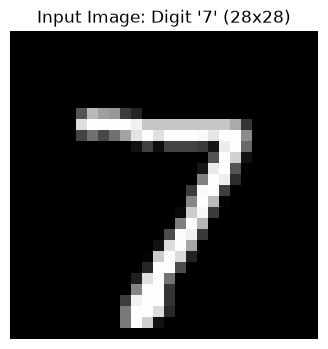

In [11]:
# Select a sample digit 7 from the test dataset
sample_idx = 0
for idx, (img, lbl) in enumerate(test_dataset):
    if lbl == 7:
        sample_idx = idx
        break

sample_img, sample_lbl = test_dataset[sample_idx]
print(f"Selected sample index {sample_idx} with true label '{sample_lbl}'")

# Print the raw 28x28 matrix to console
print("\nRaw 28x28 Input Matrix (Non-zero entries):")
arr = (sample_img.squeeze().numpy() * 255).astype(int)
for row in arr:
    print(" ".join(f"{val:3d}" if val > 0 else "  ." for val in row))

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(sample_img.squeeze(), cmap='gray')
ax.set_title(f"Input Image: Digit '{sample_lbl}' (28x28)", fontsize=12)
ax.axis('off')
plt.show()


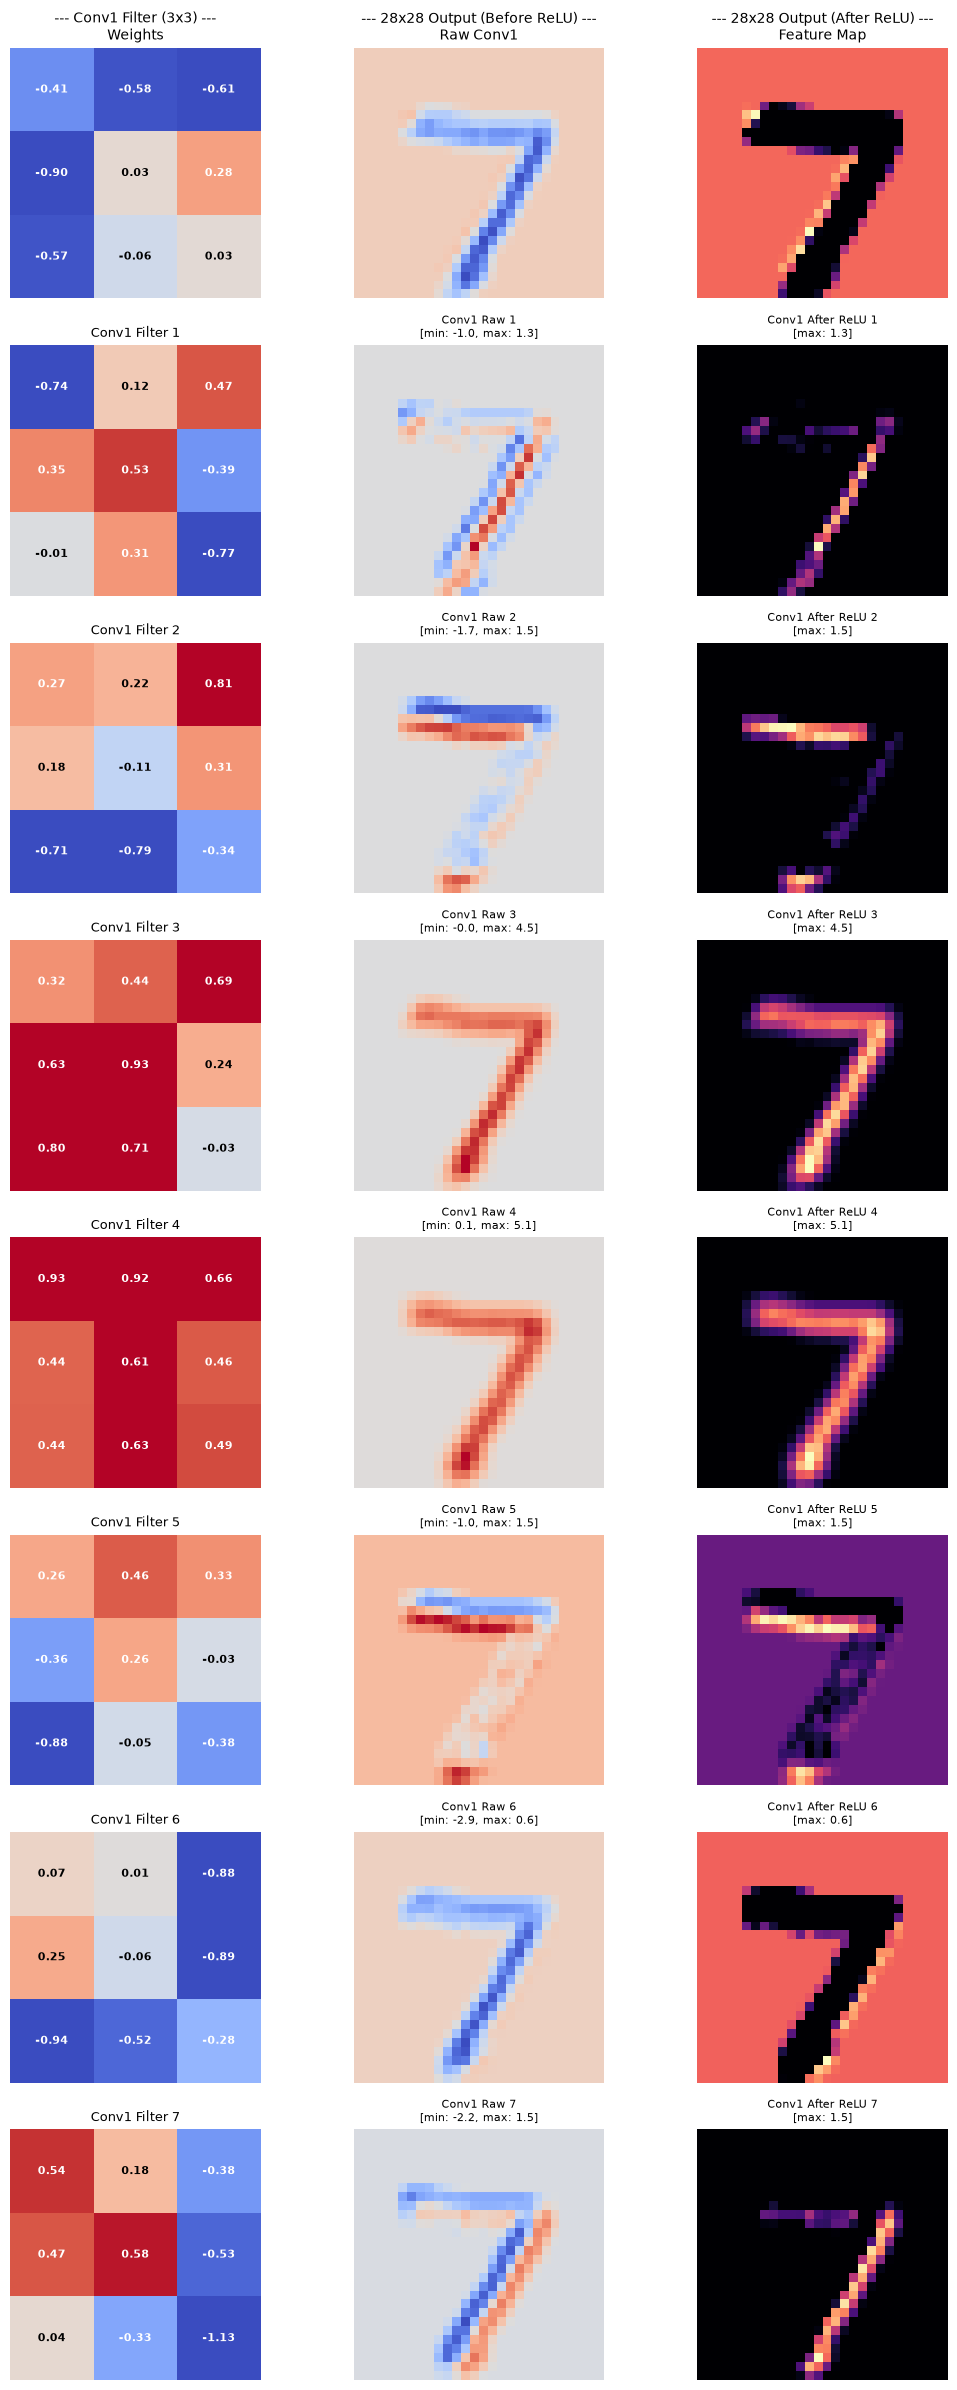

In [12]:
# --- STEP 1: Conv1 + ReLU ---
inp = sample_img.unsqueeze(0).to(device) # shape: [1, 1, 28, 28]

with torch.no_grad():
    c1_raw  = model.convolutional[0](inp)   # Conv1
    c1_relu = model.convolutional[1](c1_raw) # ReLU

conv1_w = model.convolutional[0].weight.detach().cpu()

# Plot: 8 rows x 3 columns
# Col 0: 3x3 Filter | Col 1: Before ReLU (Raw) | Col 2: After ReLU
fig, axes = plt.subplots(8, 3, figsize=(11, 24))
for i in range(8):
    f_mat = conv1_w[i, 0].numpy()
    raw_m = c1_raw[0, i].detach().cpu().numpy()
    relu_m = c1_relu[0, i].detach().cpu().numpy()
    
    # Filter 3x3 with numbers
    axes[i, 0].imshow(f_mat, cmap='coolwarm', vmin=-0.6, vmax=0.6)
    axes[i, 0].set_title(f"Conv1 Filter {i}", fontsize=9)
    axes[i, 0].axis('off')
    for (r, c), val in np.ndenumerate(f_mat):
        color = 'white' if abs(val) > 0.25 else 'black'
        axes[i, 0].text(c, r, f"{val:.2f}", ha='center', va='center', color=color, fontsize=8, fontweight='bold')
        
    # Raw Output (Before ReLU)
    lim = max(abs(raw_m.min()), abs(raw_m.max()), 1.0)
    axes[i, 1].imshow(raw_m, cmap='coolwarm', vmin=-lim, vmax=lim)
    axes[i, 1].set_title(f"Conv1 Raw {i}\n[min: {raw_m.min():.1f}, max: {raw_m.max():.1f}]", fontsize=8)
    axes[i, 1].axis('off')
    
    # After ReLU
    axes[i, 2].imshow(relu_m, cmap='magma')
    axes[i, 2].set_title(f"Conv1 After ReLU {i}\n[max: {relu_m.max():.1f}]", fontsize=8)
    axes[i, 2].axis('off')

axes[0, 0].set_title("--- Conv1 Filter (3x3) ---\nWeights", fontsize=10)
axes[0, 1].set_title("--- 28x28 Output (Before ReLU) ---\nRaw Conv1", fontsize=10)
axes[0, 2].set_title("--- 28x28 Output (After ReLU) ---\nFeature Map", fontsize=10)

plt.tight_layout()
plt.show()


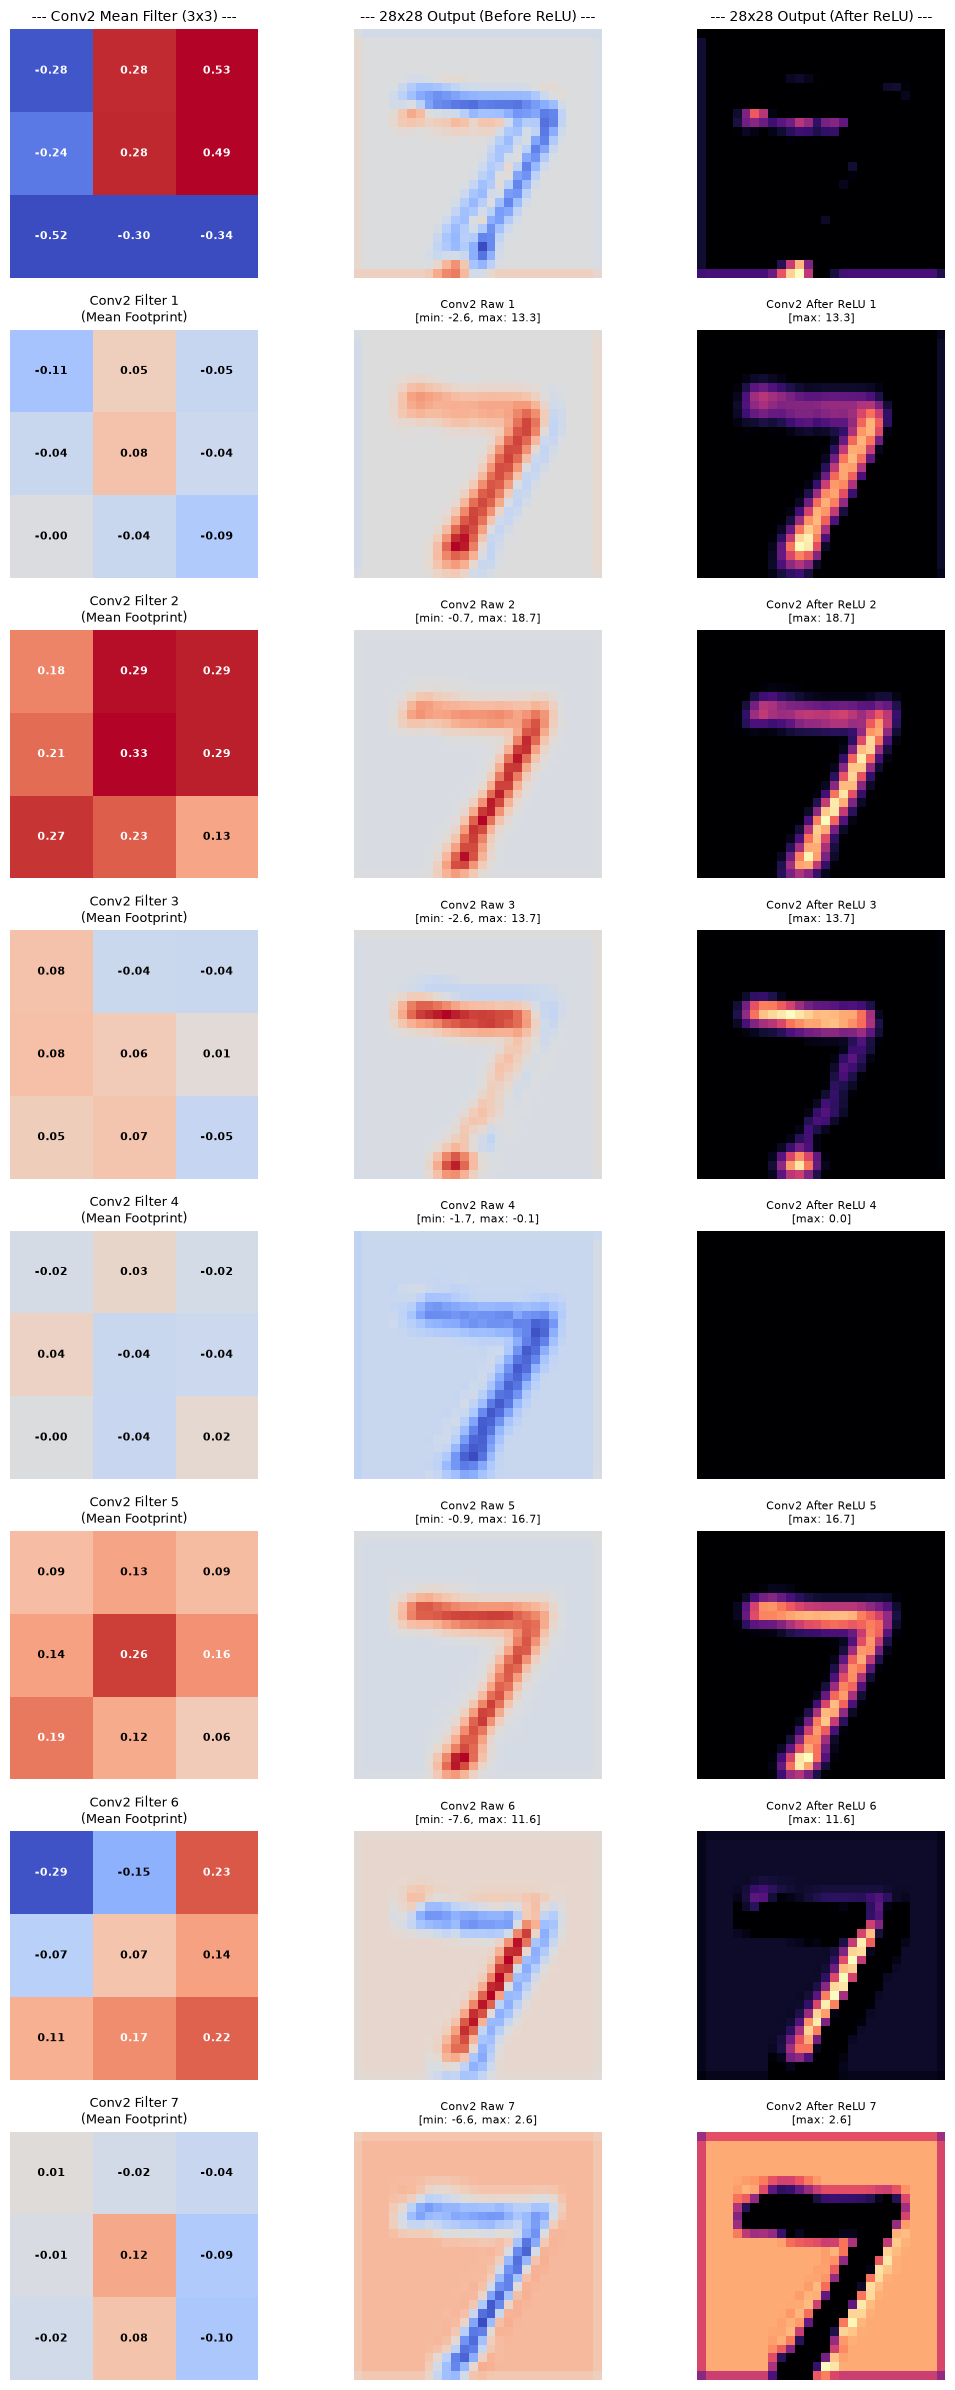

In [13]:
# --- STEP 2: Conv2 + ReLU ---
with torch.no_grad():
    c2_raw  = model.convolutional[2](c1_relu) # Conv2
    c2_relu = model.convolutional[3](c2_raw)  # ReLU

conv2_w = model.convolutional[2].weight.detach().cpu()

fig, axes = plt.subplots(8, 3, figsize=(11, 24))
for i in range(8):
    # Mean 3x3 footprint across all 8 input channels
    f_mean = conv2_w[i].mean(dim=0).numpy()
    raw_m = c2_raw[0, i].detach().cpu().numpy()
    relu_m = c2_relu[0, i].detach().cpu().numpy()
    
    # Filter footprint with numbers
    axes[i, 0].imshow(f_mean, cmap='coolwarm', vmin=-0.3, vmax=0.3)
    axes[i, 0].set_title(f"Conv2 Filter {i}\n(Mean Footprint)", fontsize=9)
    axes[i, 0].axis('off')
    for (r, c), val in np.ndenumerate(f_mean):
        color = 'white' if abs(val) > 0.15 else 'black'
        axes[i, 0].text(c, r, f"{val:.2f}", ha='center', va='center', color=color, fontsize=8, fontweight='bold')
        
    # Raw Output (Before ReLU)
    lim = max(abs(raw_m.min()), abs(raw_m.max()), 1.0)
    axes[i, 1].imshow(raw_m, cmap='coolwarm', vmin=-lim, vmax=lim)
    axes[i, 1].set_title(f"Conv2 Raw {i}\n[min: {raw_m.min():.1f}, max: {raw_m.max():.1f}]", fontsize=8)
    axes[i, 1].axis('off')
    
    # After ReLU
    axes[i, 2].imshow(relu_m, cmap='magma')
    axes[i, 2].set_title(f"Conv2 After ReLU {i}\n[max: {relu_m.max():.1f}]", fontsize=8)
    axes[i, 2].axis('off')

axes[0, 0].set_title("--- Conv2 Mean Filter (3x3) ---", fontsize=10)
axes[0, 1].set_title("--- 28x28 Output (Before ReLU) ---", fontsize=10)
axes[0, 2].set_title("--- 28x28 Output (After ReLU) ---", fontsize=10)

plt.tight_layout()
plt.show()


Shape before pooling: torch.Size([1, 8, 28, 28])
Shape after pooling:  torch.Size([1, 8, 14, 14])


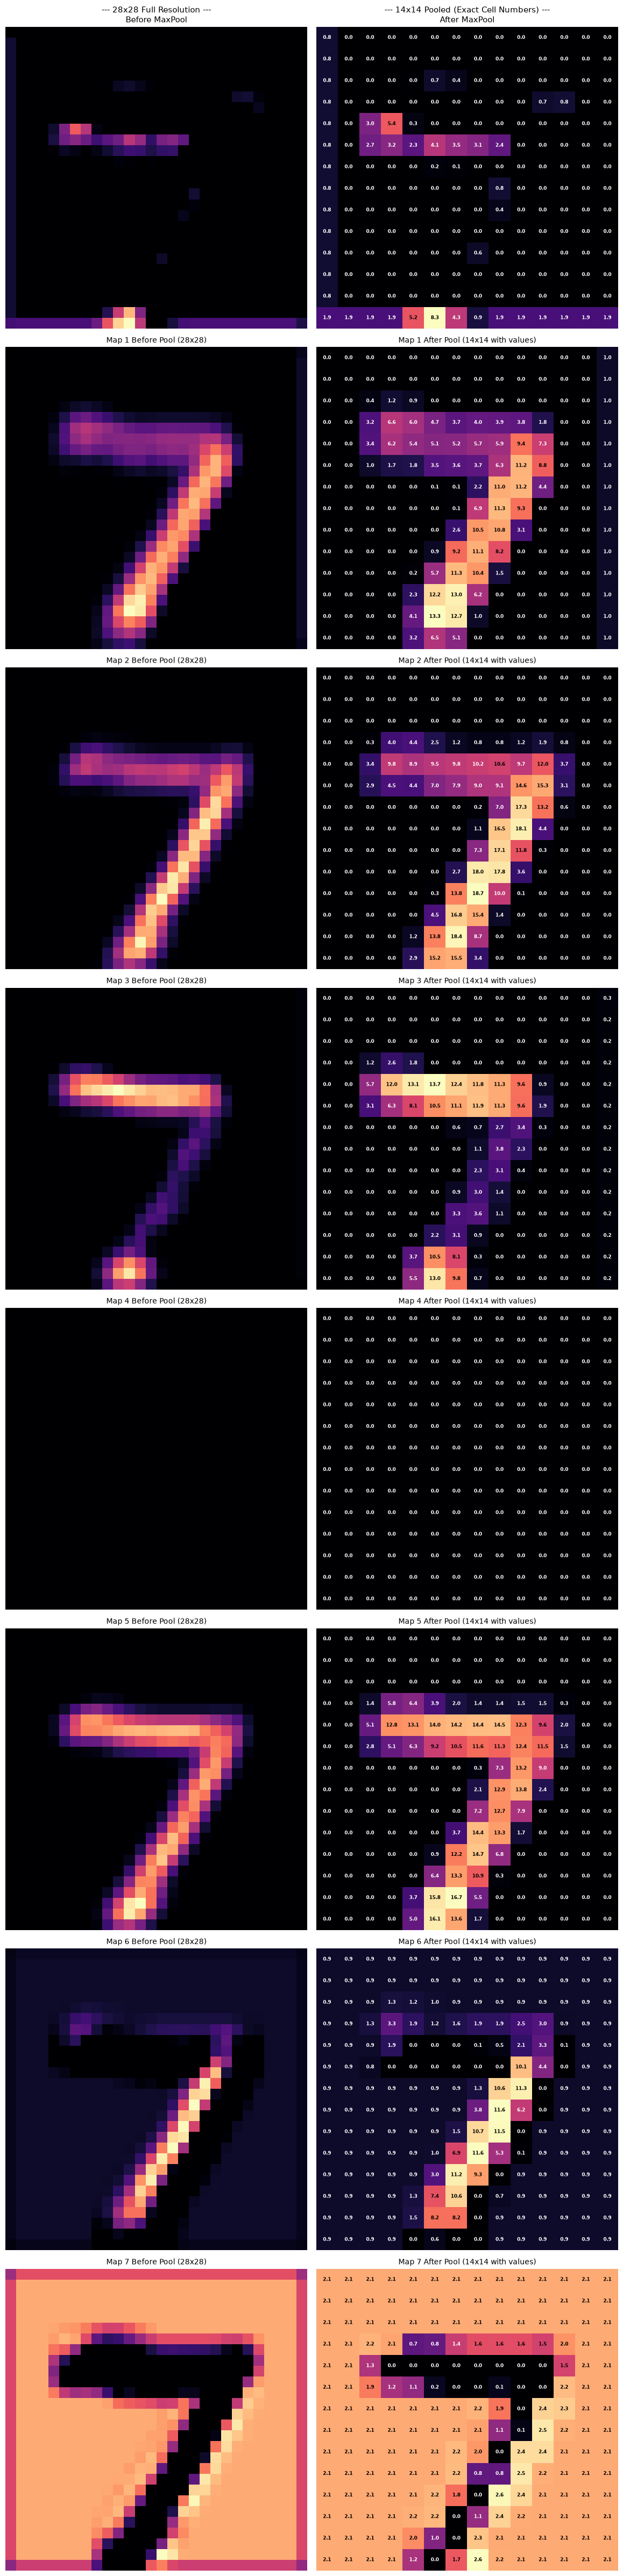

In [14]:
# --- STEP 3: MaxPool2d (28x28 -> 14x14) ---
with torch.no_grad():
    pooled = model.convolutional[4](c2_relu)  # shape: [1, 8, 14, 14]

print(f"Shape before pooling: {c2_relu.shape}")
print(f"Shape after pooling:  {pooled.shape}")

# Side-by-side comparison: Full 28x28 vs Pooled 14x14 (with exact cell numbers)
fig, axes = plt.subplots(8, 2, figsize=(12, 48))

for i in range(8):
    m28 = c2_relu[0, i].detach().cpu().numpy()
    m14 = pooled[0, i].detach().cpu().numpy()
    
    # 28x28 Map
    axes[i, 0].imshow(m28, cmap='magma')
    axes[i, 0].set_title(f"Map {i} Before Pool (28x28)", fontsize=10)
    axes[i, 0].axis('off')
    
    # 14x14 Map with numbers on every cell
    axes[i, 1].imshow(m14, cmap='magma', interpolation='nearest')
    axes[i, 1].set_title(f"Map {i} After Pool (14x14 with values)", fontsize=10)
    max_v = m14.max()
    for r in range(14):
        for c in range(14):
            val = m14[r, c]
            color = 'black' if (max_v > 0 and val > max_v * 0.55) else 'white'
            axes[i, 1].text(c, r, f"{val:.1f}", ha='center', va='center', color=color, fontsize=6.5, fontweight='bold')
    axes[i, 1].axis('off')

axes[0, 0].set_title("--- 28x28 Full Resolution ---\nBefore MaxPool", fontsize=11)
axes[0, 1].set_title("--- 14x14 Pooled (Exact Cell Numbers) ---\nAfter MaxPool", fontsize=11)

plt.tight_layout()
plt.show()


Conv3 Output Shape: torch.Size([1, 16, 14, 14])
Conv4 Output Shape: torch.Size([1, 16, 14, 14])


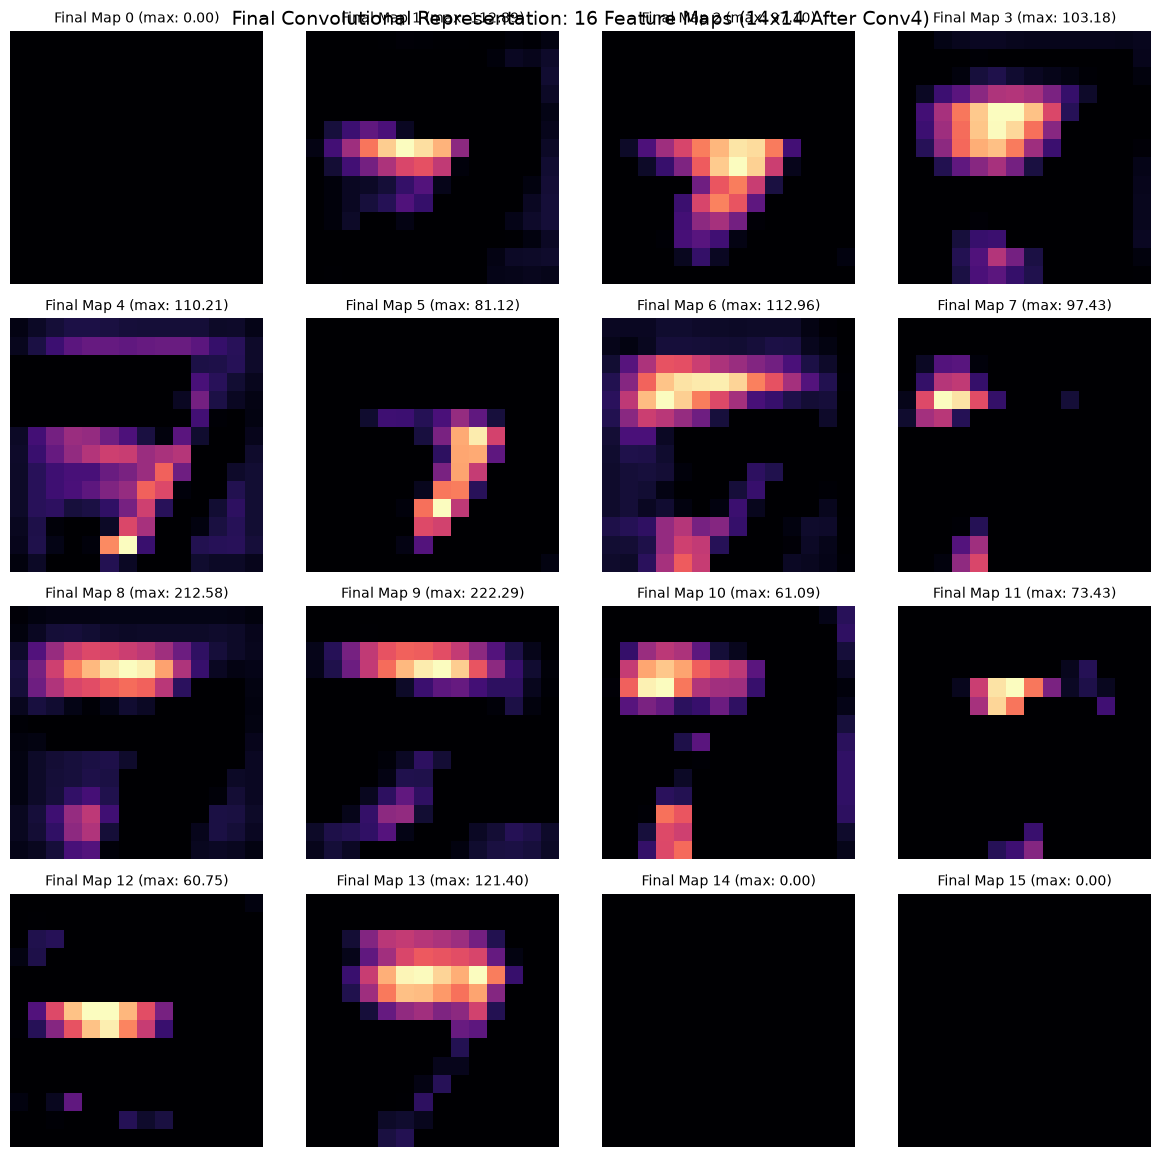

In [15]:
# --- STEP 4 & 5: Conv3 and Conv4 (Block 2 - 16 Feature Maps) ---
with torch.no_grad():
    c3_raw  = model.convolutional[5](pooled)
    c3_relu = model.convolutional[6](c3_raw)
    
    c4_raw  = model.convolutional[7](c3_relu)
    c4_relu = model.convolutional[8](c4_raw)

print(f"Conv3 Output Shape: {c3_relu.shape}")
print(f"Conv4 Output Shape: {c4_relu.shape}")

# Plot all 16 maps of Conv4 (the final convolutional representations)
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i in range(16):
    r, c = divmod(i, 4)
    m = c4_relu[0, i].detach().cpu().numpy()
    axes[r, c].imshow(m, cmap='magma', interpolation='nearest')
    axes[r, c].set_title(f"Final Map {i} (max: {m.max():.2f})", fontsize=10)
    axes[r, c].axis('off')

plt.suptitle("Final Convolutional Representation: 16 Feature Maps (14x14 After Conv4)", fontsize=14, y=0.96)
plt.tight_layout()
plt.show()


 THE 16-DIMENSIONAL GLOBAL SUMMARY VECTOR (From Global Avg Pooling)
Feature  0 average score:  0.000
Feature  1 average score:  7.377
Feature  2 average score:  8.804
Feature  3 average score: 12.971
Feature  4 average score: 15.164
Feature  5 average score:  5.681
Feature  6 average score: 19.166
Feature  7 average score:  4.275
Feature  8 average score: 28.054
Feature  9 average score: 20.554
Feature 10 average score:  6.389
Feature 11 average score:  2.748
Feature 12 average score:  3.501
Feature 13 average score: 15.490
Feature 14 average score:  0.000
Feature 15 average score:  0.000

Predicted Class: 7 (Confidence: 99.98%)
Ground Truth:    7


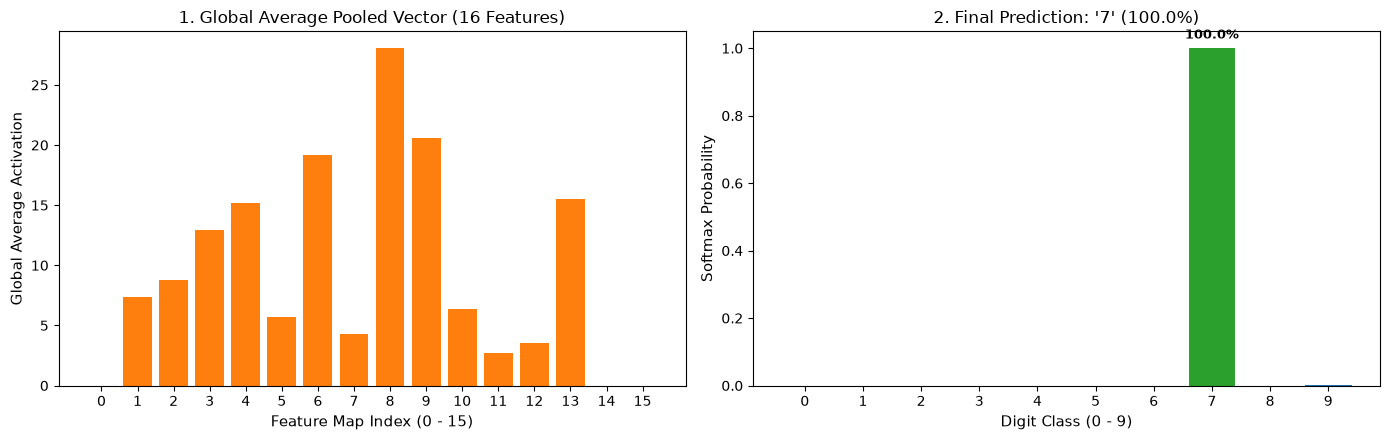

In [16]:
# --- STEP 6: Global Average Pooling (GAP) -> Vector of 16 Numbers ---
with torch.no_grad():
    # 1. Global Average Pooling: averages each of the 16 (14x14) maps down to 1 number
    gap_out = model.gap(c4_relu)       # shape: [1, 16, 1, 1]
    vector_16 = gap_out.view(1, -1)     # shape: [1, 16]
    
    # 2. Classifier: Linear(16 -> 10)
    logits = model.classifier(vector_16)
    probs = F.softmax(logits, dim=1).cpu().squeeze().numpy()

v16_np = vector_16.cpu().squeeze().numpy()

print("=" * 65)
print(" THE 16-DIMENSIONAL GLOBAL SUMMARY VECTOR (From Global Avg Pooling)")
print("=" * 65)
for i in range(16):
    print(f"Feature {i:2d} average score: {v16_np[i]:6.3f}")
print("=" * 65)

predicted_digit = np.argmax(probs)
confidence = probs[predicted_digit] * 100

print(f"\nPredicted Class: {predicted_digit} (Confidence: {confidence:.2f}%)")
print(f"Ground Truth:    {sample_lbl}")

# Plot: Left = The 16 Global Feature Scores | Right = Final 10-Class Softmax Probabilities
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Left plot: The 16 features from GAP
bars1 = ax1.bar(range(16), v16_np, color='#ff7f0e')
ax1.set_xticks(range(16))
ax1.set_xlabel('Feature Map Index (0 - 15)', fontsize=11)
ax1.set_ylabel('Global Average Activation', fontsize=11)
ax1.set_title('1. Global Average Pooled Vector (16 Features)', fontsize=12)

# Right plot: Softmax probabilities
bars2 = ax2.bar(range(10), probs, color=['#1f77b4' if i != predicted_digit else '#2ca02c' for i in range(10)])
ax2.set_xticks(range(10))
ax2.set_xlabel('Digit Class (0 - 9)', fontsize=11)
ax2.set_ylabel('Softmax Probability', fontsize=11)
ax2.set_title(f"2. Final Prediction: '{predicted_digit}' ({confidence:.1f}%)", fontsize=12)
ax2.set_ylim(0, 1.05)

for bar in bars2:
    h = bar.get_height()
    if h > 0.005:
        ax2.text(bar.get_x() + bar.get_width()/2., h + 0.02, f"{h*100:.1f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


Here is your **Field Guide to Reading Every Plot** in the notebook. 

Once you know the visual language of these plots, you can look at any convolutional network and immediately "see" what the AI is thinking.

---

## 1. The 3×3 Filter Plot (The Template)

```
        ┌─────────┬─────────┬─────────┐
        │  -0.37  │  +0.16  │  +0.31  │  (Blue = Negative, Red = Positive)
        ├─────────┼─────────┼─────────┤
        │  -0.01  │  -0.19  │  +0.29  │
        ├─────────┼─────────┼─────────┤
        │  -0.07  │  +0.15  │  +0.38  │
        └─────────┴─────────┴─────────┘
```

* **The Colormap (`coolwarm`):**
  * 🔴 **Red (+)** = The filter **wants light/ink** here.
  * 🔵 **Blue (−)** = The filter **wants darkness/background** here.
  * ⚪ **White (0)** = The filter **ignores** this pixel.
* **How to read the shape of the numbers:**
  * **Left Blue, Right Red:** *"I look for dark-to-light vertical edges."*
  * **Top Blue, Bottom Red:** *"I look for horizontal lines."*
  * **All Red:** *"I look for solid ink (presence/blur)."*
  * **Red Center, Blue Edges:** *"I look for thin isolated strokes/dots."*

---

## 2. The Raw Output Matrix (Before ReLU)

```
  Colormap: coolwarm (Centered at 0.0)
  Range: [min: -0.55, max: +0.93]
```

* 🔴 **Reddish regions:** **Excitation (A Match!).**  
  The filter landed on pixels that matched its weights. The higher the positive number, the stronger the match.
* 🔵 **Bluish regions:** **Inhibition (Opposite Polarity).**  
  The filter hit the *opposite* of what it wanted. (For example, bright ink landed on negative weights).
* ⚪ **Off-white background:** **Neutral ($0.0$).**  
  Blank background pixels where $0 \times \text{weight} = 0$.

> **Key Rule to Look For:** On an edge detector, look for a **red line accompanied by a blue "shadow" right beside it**. The red is where the edge started, and the blue is where it ended!

---

## 3. The Output Matrix (After ReLU)

```
  Colormap: magma (0.0 = Pure Black, High = Glowing Yellow/White)
```

* **Pitch Black ($0.0$):**  
  Notice that **all the blue regions from the raw plot are gone!** ReLU has one job: $\max(0, x)$. Anything negative is instantly killed off.
* **Glowing Orange/Yellow:**  
  These are the surviving positive features that get passed forward as inputs to the next layer.
* **How to read it:** If a filter is a "Horizontal Edge Detector", you will see **only the top bar of the `7` glowing**, while the rest of the image is completely blacked out.

---

## 4. The 14×14 MaxPool Plot with Numbers

```
       0.0   0.0   0.0   0.0   0.0
       0.0   0.8   1.2   0.0   0.0   <-- You can trace the digit!
       0.0   0.0   0.9   0.0   0.0
```

* **Why it's blockier:** It reduced $28 \times 28$ ($784$ numbers) down to $14 \times 14$ ($196$ numbers).
* **How to read the cell numbers:**
  * **Zeros (`0.0`):** Pure background where no feature was found.
  * **High numbers (`> 1.0`):** The exact coordinates where the feature was detected at maximum intensity.
  * You can literally **trace the skeleton of the digit** by following the non-zero cells!

---

## 5. The 16 Global Feature Scores (From Global Average Pooling)

```
Activation
  2.5 │         █
  1.8 │   █     █
  0.2 │ █ █ _ _ █ _ █ _ _ _ █ _ _ _
      └───┴─┴─┴─┴─┴─┴─┴─┴─┴─┴─┴─┴─┴───
          0 1 2 3 4 5 6 7 8 ...   15  (Feature Map Index)
```

* **What the bars mean:**  
  Each bar represents **one entire $14 \times 14$ feature map from Conv4**, averaged down into a single number.
* **How to read it:**  
  This is the **"Digital Fingerprint" or "Barcode"** of the input image!
  * If the input is a **`7`**: Feature 1 (horizontal top bar) and Feature 5 (diagonal stroke) will have **tall bars**, while Feature 8 (loop detector for `8` or `0`) will be **flat at zero**.
  * If the input was an **`8`**, an entirely different combination of bars would shoot up!

---

## 6. The Final 10-Class Prediction Bar Chart

```
Prob
 100% │                     █ (99.4%)
      │                     │
   0% └───┴───┴───┴───┴───┴─┴─┴───┴───┴───
          0   1   2   3   4 5 6 7   8   9  (Digits)
```

* **10 Columns:** Digits `0` through `9`.
* **Bar Height:** The Softmax confidence ($0\%$ to $100\%$).
* **Green Bar:** The winner! (e.g., Digit `7` with $99.4\%$ confidence).
* **Other Bars:** Show any slight confusion (e.g., if a handwritten `7` has a curved top, it might have a tiny $0.5\%$ bar on digit `1` or `2`).

---

### Quick Summary Checklist When Looking at the Notebook:
1. **Filters:** Look for red vs. blue patterns (edges, blobs, corners).
2. **Raw Output:** Red = detected, Blue = suppressed.
3. **After ReLU:** Only the detected outlines survive (yellow/orange).
4. **GAP Vector:** The 16-number barcode summarizing what parts were found.
5. **Softmax:** The final decision based on that 16-number barcode.

---

How do 16 feature numbers turn into 10 probabilities? 

It happens in **two simple, beautiful mathematical steps**:

$$\text{Vector of 16 Numbers} \xrightarrow[\text{Step 1: 10 Weighted Votes}]{\text{Linear}(16, 10)} \mathbf{10 \text{ Raw Scores (Logits)}} \xrightarrow[\text{Step 2: Normalization}]{\text{Softmax}} \mathbf{10 \text{ Probabilities (Sum = 100\%)}}$$

---

### Step 1: The Linear Layer (`nn.Linear(16, 10)`) $\longrightarrow$ 10 Voting Equations

Think of the 16 numbers as **16 clues**.  
There are 10 possible digit suspects (`0` to `9`). 

Each digit suspect has its own personal **scoring formula** (16 weights + 1 bias):

$$\text{Score for Digit 0} = (w_{0,0} \cdot x_0) + (w_{0,1} \cdot x_1) + \dots + (w_{0,15} \cdot x_{15}) + \text{bias}_0$$
$$\text{Score for Digit 1} = (w_{1,0} \cdot x_0) + (w_{1,1} \cdot x_1) + \dots + (w_{1,15} \cdot x_{15}) + \text{bias}_1$$
$$\dots$$
$$\text{Score for Digit 7} = (w_{7,0} \cdot x_0) + (w_{7,1} \cdot x_1) + \dots + (w_{7,15} \cdot x_{15}) + \text{bias}_7$$

#### What the weights mean intuitively:
* **The Digit 7 formula** learns **large positive weights** for:
  * Clue 4: *Horizontal Top Bar* ($+2.5$)
  * Clue 5: *Diagonal Stroke* ($+3.1$)
  * ...and **large negative weights** for:
  * Clue 8: *Round Loop* ($-4.0$) $\longrightarrow$ *"If there is a loop, this is definitely NOT a 7!"*
* **The Digit 8 formula**, on the other hand, gives huge positive points to *Round Loop*!

---

### Step 2: The Raw Scores (Logits)

After running all 10 equations, you get **10 raw scores** (called *logits*).  
For your image of a `7`, they might look like this:

| Digit | 0 | 1 | 2 | 3 | 4 | 5 | 6 | **7** | 8 | 9 |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Raw Score** | $-2.1$ | $+1.2$ | $-0.5$ | $-1.8$ | $-0.2$ | $-3.0$ | $-4.1$ | $\mathbf{+8.5}$ | $-1.1$ | $+0.4$ |

Notice:
1. Some scores are negative.
2. They do **not** add up to $1$ or $100\%$.

---

### Step 3: The Softmax Function $\longrightarrow$ Turning Scores into %

Softmax takes those 10 raw scores and does two things:

1. **Takes $e^{\text{score}}$ (the exponential):**  
   * This guarantees every number becomes **strictly positive** ($e^{-2.1} = 0.12$, $e^{8.5} = 4914.7$).
   * It also magnifies the winner.
2. **Divides by the grand total:**  
   $$P(\text{Digit } k) = \frac{e^{\text{Score}_k}}{\sum_{j=0}^9 e^{\text{Score}_j}}$$

$$\text{Final Probabilities}: \quad \begin{cases} P(\text{Digit 0}) = 0.00\% \\ P(\text{Digit 1}) = 0.07\% \\ \dots \\ \mathbf{P(\text{Digit 7}) = 99.82\%} \\ \dots \\ P(\text{Digit 9}) = 0.03\% \end{cases}$$

All 10 probabilities are now between $0\%$ and $100\%$, and their sum is **exactly $100\%$**!

---

### In Summary:
* **The 16 numbers** = The measurements of 16 visual features.
* **The $10 \times 16$ matrix** = 10 separate recipes calculating how much those 16 features match each digit $0$ through $9$.
* **Softmax** = Normalizes those 10 scores into clean percentages so you can pick the winner!

### What is a "Receptive Field"?

> The **Receptive Field** is the patch of pixels in the **original input image** that a single neuron actually "sees" and is influenced by.

---

### The Peephole Analogy

Imagine looking at a painting through a tiny cardboard tube:

```
Layer 1: You look through a tiny tube   ──► You only see 3x3 pixels.
                                            (Can only detect: "is there an edge here?")

Layer 2: You step back                 ──► You see 5x5 pixels.
                                            (Can detect: "two edges meeting into a corner")

Deeper:  You step further back         ──► You see 14x14 pixels.
                                            (Can detect: "a loop or a diagonal stroke")

GAP:     You step back completely      ──► You see the full 28x28 painting!
                                            (Can detect: "this whole object is a '7'")
```

---

### How the Receptive Field Grows in YOUR Network:

Let's trace **one single pixel** through your exact layers:

#### 1. Input Image
* 1 pixel on the input image sees: **$1 \times 1$** (itself).

#### 2. After Conv 1 ($3 \times 3$ filter, stride 1)
* 1 pixel in Conv1 is computed from a $3 \times 3$ patch of the input.
* **Receptive field = $3 \times 3$ pixels.**
* *What it can understand:* Tiny local textures and edge slopes.

#### 3. After Conv 2 ($3 \times 3$ filter, stride 1)
* 1 pixel in Conv2 looks at a $3 \times 3$ area of Conv1.
* But each of those Conv1 pixels was already seeing $3 \times 3$ of the input!
* Stacking two $3 \times 3$ filters expands the field of view:
  $$3 + (3 - 1) = \mathbf{5 \times 5 \text{ pixels}}$$
* **Receptive field = $5 \times 5$ pixels.**
* *What it can understand:* Corners, T-junctions, small curves.

#### 4. After MaxPool ($2 \times 2$, stride 2)
* Pooling takes a $2 \times 2$ block of Conv2 pixels and keeps the max.
* **Receptive field doubles to $\mathbf{6 \times 6}$ pixels**, and more importantly: **every future step now covers $2\times$ more distance on the original image!**

#### 5. After Conv 3 ($3 \times 3$) and Conv 4 ($3 \times 3$)
* Because of the pooling stride, each $3 \times 3$ step in Conv 3 and Conv 4 covers large jumps across the original image.
* After Conv 3: **$\approx 10 \times 10$ pixels.**
* After Conv 4: **$\approx 14 \times 14$ pixels.**
* *What it can understand:* Entire stroke branches, loops of an `8`, the full top-bar of a `7`.

#### 6. After Global Average Pooling (GAP)
* GAP averages across the **entire $14 \times 14$ map**.
* **Receptive field = $\mathbf{28 \times 28 \text{ pixels}}$ (the entire image!).**
* *What it can understand:* The whole digit as an integrated object.

---

### Why Does This Matter?

If a network's receptive field is **too small**, it literally **cannot see the whole object**:
* If a neuron in the final layer only had an $8 \times 8$ receptive field on a $28 \times 28$ image, it could never tell the difference between a `7` and a `1`, because the bottom of the stroke and the top bar would be too far apart for any single neuron to see both at once!
* By expanding the receptive field layer-by-layer, CNNs build a natural **visual hierarchy**:

$$\text{Pixels } (1 \times 1) \longrightarrow \text{Edges } (3 \times 3) \longrightarrow \text{Corners } (5 \times 5) \longrightarrow \text{Parts } (14 \times 14) \longrightarrow \text{Whole Object } (28 \times 28)$$

$$\mathbf{\text{Output Size}} = \left\lfloor \frac{W - K + 2P}{S} \right\rfloor + 1$$

Here is the formula, calculation, and conceptual comparison for counting parameters in **Convolutional** vs. **Fully Connected** layers:

---

### 1. The General Formulas

#### A. Convolutional Layer (`nn.Conv2d`)
$$\mathbf{\text{Params}} = \underbrace{(C_{\text{in}} \times K_H \times K_W \times C_{\text{out}})}_{\text{Weights}} + \underbrace{C_{\text{out}}}_{\text{Biases}}$$

* $C_{\text{in}}$ = Number of input channels
* $C_{\text{out}}$ = Number of output filters
* $K_H, K_W$ = Kernel height and width (e.g. $3 \times 3$)
* **Crucial Rule:** The parameter count **does NOT depend on image size** ($28 \times 28$ vs. $1000 \times 1000$ uses the exact same number of weights!).

#### B. Fully Connected Layer (`nn.Linear`)
$$\mathbf{\text{Params}} = \underbrace{(N_{\text{in}} \times N_{\text{out}})}_{\text{Weights}} + \underbrace{N_{\text{out}}}_{\text{Biases}}$$

* $N_{\text{in}}$ = Number of input features
* $N_{\text{out}}$ = Number of output neurons
* **Crucial Rule:** If the input comes from flattened feature maps, $N_{\text{in}} = C \times H \times W$, which causes an **explosive parameter bloat**.

---

### 2. Concrete Counts for YOUR Network

#### Convolutional Part (4 Layers):
| Layer | Specification | Weights Formula | Weights | Biases | Total |
| :--- | :--- | :--- | :---: | :---: | :---: |
| **Conv 1** | `in: 1, out: 8, 3x3` | $8 \times (1 \times 3 \times 3)$ | 72 | 8 | **80** |
| **Conv 2** | `in: 8, out: 8, 3x3` | $8 \times (8 \times 3 \times 3)$ | 576 | 8 | **584** |
| **Conv 3** | `in: 8, out: 16, 3x3` | $16 \times (8 \times 3 \times 3)$ | 1,152 | 16 | **1,168** |
| **Conv 4** | `in: 16, out: 16, 3x3` | $16 \times (16 \times 3 \times 3)$ | 2,304 | 16 | **2,320** |
| **Total Conv** | | | **4,104** | **48** | **4,152** |

*(MaxPool has **0** parameters).*

---

#### Fully Connected Part: Traditional vs. Global Average Pooling (GAP)

##### Option 1: Traditional Flattening (`16 x 14 x 14 = 3,136` inputs)
| Layer | Specification | Weights Formula | Weights | Biases | Total |
| :--- | :--- | :--- | :---: | :---: | :---: |
| **Linear 1** | `3136 → 500` | $500 \times 3,136$ | 1,568,000 | 500 | **1,568,500** |
| **Linear 2** | `500 → 10` | $10 \times 500$ | 5,000 | 10 | **5,010** |
| **Total FC** | | | **1,573,000** | **510** | **1,573,510** |

##### Option 2: Modern Global Average Pooling (`16` inputs)
| Layer | Specification | Weights Formula | Weights | Biases | Total |
| :--- | :--- | :--- | :---: | :---: | :---: |
| **GAP** | `14x14 → 1` | *(no parameters)* | 0 | 0 | **0** |
| **Linear** | `16 → 10` | $10 \times 16$ | 160 | 10 | **170** |
| **Total FC** | | | **160** | **10** | **170** |

---

### 3. The Comparison at a Glance

| Model Type | Conv Parameters | Fully Connected Parameters | Total Parameters | % in FC |
| :--- | :---: | :---: | :---: | :---: |
| **Traditional (500 neurons)** | 4,152 | **1,573,510** | **1,577,662** | **99.74%** |
| **With GAP (Modern)** | 4,152 | **170** | **4,322** | **3.93%** |

---

### Key Takeaway for Exams / Interviews
* **Convolutional layers** are drastically more parameter-efficient because of **weight sharing** (the same 9 weights slide over every pixel).
* **Fully connected layers** cause severe parameter explosions when connected to high-resolution spatial maps, which is why modern architectures use **Global Average Pooling** to eliminate them.